# CSE422 AI Project: Tree Sterility Prediction

This notebook follows the project sequence:

**Load Dataset → EDA + Preprocessing → Train/Validation/Test Split → Scaling/Normalization → Train Supervised Models + K-Means → Model Evaluation**

Target column: `Sterile`  
Problem type: Binary Classification

In [ ]:
# Cell 1: Import Libraries

# Basic data handling libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Google Colab file upload
from google.colab import files
import io

# Data splitting and preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Supervised machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

# Model evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

# Unsupervised learning and dimensionality reduction
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# For graph layout
import math

In [ ]:
# Cell 2: Upload Dataset

# Upload the Tree_Sterility_Dataset.csv file from your computer
uploaded = files.upload()

Saving Tree_Sterility_Dataset.csv to Tree_Sterility_Dataset.csv


In [ ]:
# Cell 3: Load Dataset

# Read the uploaded CSV file
# This method works even if Colab renames the uploaded file
uploaded_filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[uploaded_filename]))

# Show first 5 rows
df.head()

,No,Plot,Subplot,Species,Light_ISF,Light_Cat,Core,Soil,Adult,Sterile,...,AMF,EMF,Phenolics,Lignin,NSC,Census,Time,Event,Harvest,Alive
0,126,1,C,Acer saccharum,0.106,Med,2017,Prunus serotina,I,Non-Sterile,...,22.00,NaN,-0.56,13.86,12.15,4,14.0,1.0,NaN,NaN
1,11,1,C,Quercus alba,0.106,Med,2017,Quercus rubra,970,Non-Sterile,...,15.82,31.07,5.19,20.52,19.29,33,115.5,0.0,NaN,X
2,12,1,C,Quercus rubra,0.106,Med,2017,Prunus serotina,J,Non-Sterile,...,24.45,28.19,3.36,24.74,15.01,18,63.0,1.0,NaN,NaN
3,2823,7,D,Acer saccharum,0.080,Med,2016,Prunus serotina,J,Non-Sterile,...,22.23,NaN,-0.71,14.29,12.36,4,14.0,1.0,NaN,NaN
4,5679,14,A,Acer saccharum,0.060,Low,2017,Prunus serotina,689,Non-Sterile,...,21.15,NaN,-0.58,10.85,11.20,4,14.0,1.0,NaN,NaN


In [ ]:
# Cell 4: Basic Dataset Information

# Check dataset size, columns, data types, summary, and missing values

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe(include="all"))

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (2783, 24)

Column Names:
['No', 'Plot', 'Subplot', 'Species', 'Light_ISF', 'Light_Cat', 'Core', 'Soil', 'Adult', 'Sterile', 'Conspecific', 'Myco', 'SoilMyco', 'PlantDate', 'AMF', 'EMF', 'Phenolics', 'Lignin', 'NSC', 'Census', 'Time', 'Event', 'Harvest', 'Alive']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2783 entries, 0 to 2782
Data columns (total 24 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   No           2783 non-null   int64  
 1   Plot         2783 non-null   int64  
 2   Subplot      2783 non-null   object 
 3   Species      2783 non-null   object 
 4   Light_ISF    2783 non-null   float64
 5   Light_Cat    2783 non-null   object 
 6   Core         2783 non-null   int64  
 7   Soil         2783 non-null   object 
 8   Adult        2783 non-null   object 
 9   Sterile      2783 non-null   object 
 10  Conspecific  2783 non-null   object 
 11  Myco         2783 non-null   object 
 12 

,No,Plot,Subplot,Species,Light_ISF,Light_Cat,Core,Soil,Adult,Sterile,...,AMF,EMF,Phenolics,Lignin,NSC,Census,Time,Event,Harvest,Alive
count,2783.000000,2783.000000,2783,2783,2783.000000,2783,2783.000000,2783,2783,2783,...,2783.000000,1283.00000,2783.000000,2783.000000,2783.000000,2783.000000,2783.000000,2782.000000,704,491
unique,NaN,NaN,5,4,NaN,3,NaN,7,36,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1
top,NaN,NaN,A,Acer saccharum,NaN,Med,NaN,Sterile,I,Non-Sterile,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,X,X
freq,NaN,NaN,701,751,NaN,1474,NaN,423,90,2360,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,704,491
mean,3914.513834,9.561624,NaN,NaN,0.085707,NaN,2016.648940,NaN,NaN,NaN,...,20.553069,26.47675,1.933105,15.759792,14.219641,15.282070,53.487244,0.570453,NaN,NaN
std,2253.515063,5.203659,NaN,NaN,0.025638,NaN,0.477387,NaN,NaN,NaN,...,12.309587,16.63689,1.969842,6.779607,4.298271,9.166555,32.082942,0.495100,NaN,NaN
min,3.000000,1.000000,NaN,NaN,0.032000,NaN,2016.000000,NaN,NaN,NaN,...,0.000000,0.00000,-1.350000,2.230000,4.300000,4.000000,14.000000,0.000000,NaN,NaN
25%,1971.000000,5.000000,NaN,NaN,0.066000,NaN,2016.000000,NaN,NaN,NaN,...,13.400000,13.78000,0.170000,10.355000,11.605000,7.000000,24.500000,0.000000,NaN,NaN
50%,3932.000000,10.000000,NaN,NaN,0.082000,NaN,2017.000000,NaN,NaN,NaN,...,18.000000,27.72000,0.750000,14.040000,12.660000,13.000000,45.500000,1.000000,NaN,NaN
75%,5879.000000,14.000000,NaN,NaN,0.100000,NaN,2017.000000,NaN,NaN,NaN,...,24.445000,35.71000,3.780000,21.115000,17.275000,18.000000,63.000000,1.000000,NaN,NaN



Missing Values:
No                0
Plot              0
Subplot           0
Species           0
Light_ISF         0
Light_Cat         0
Core              0
Soil              0
Adult             0
Sterile           0
Conspecific       0
Myco              0
SoilMyco          0
PlantDate         0
AMF               0
EMF            1500
Phenolics         0
Lignin            0
NSC               0
Census            0
Time              0
Event             1
Harvest        2079
Alive          2292
dtype: int64


In [ ]:
# Cell 5: Target Column Information

# Our target/output column is Sterile
# This column tells whether the sample is Sterile or Non-Sterile

target_column = "Sterile"

print("Target Column:", target_column)

print("\nTarget Class Distribution:")
print(df[target_column].value_counts())

print("\nTarget Class Percentage:")
print(df[target_column].value_counts(normalize=True) * 100)

Target Column: Sterile

Target Class Distribution:
Sterile
Non-Sterile    2360
Sterile         423
Name: count, dtype: int64

Target Class Percentage:
Sterile
Non-Sterile    84.800575
Sterile        15.199425
Name: proportion, dtype: float64


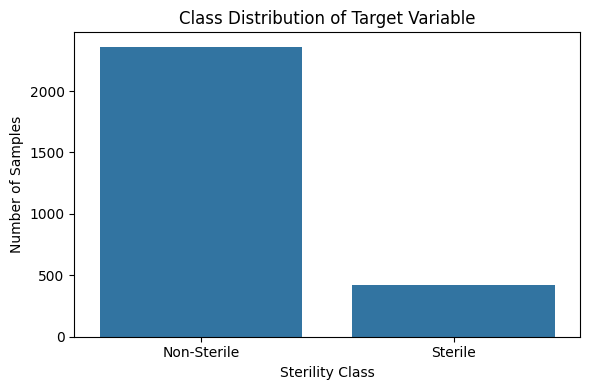

In [ ]:
# Cell 6: Class Distribution Bar Chart

# This chart shows whether the dataset is balanced or imbalanced

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=target_column)

plt.title("Class Distribution of Target Variable")
plt.xlabel("Sterility Class")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.show()

In [ ]:
# Cell 7: Numerical and Categorical Columns

# Separate numerical and categorical columns
# Numerical columns contain numbers
# Categorical columns contain text/categories

categorical_columns = df.select_dtypes(include=["object"]).columns.tolist()
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical Columns:")
print(categorical_columns)

print("\nNumerical Columns:")
print(numerical_columns)

print("\nNumber of Categorical Columns:", len(categorical_columns))
print("Number of Numerical Columns:", len(numerical_columns))

Categorical Columns:
['Subplot', 'Species', 'Light_Cat', 'Soil', 'Adult', 'Sterile', 'Conspecific', 'Myco', 'SoilMyco', 'PlantDate', 'Harvest', 'Alive']

Numerical Columns:
['No', 'Plot', 'Light_ISF', 'Core', 'AMF', 'EMF', 'Phenolics', 'Lignin', 'NSC', 'Census', 'Time', 'Event']

Number of Categorical Columns: 12
Number of Numerical Columns: 12


Columns with Missing Values:
EMF        1500
Event         1
Harvest    2079
Alive      2292
dtype: int64


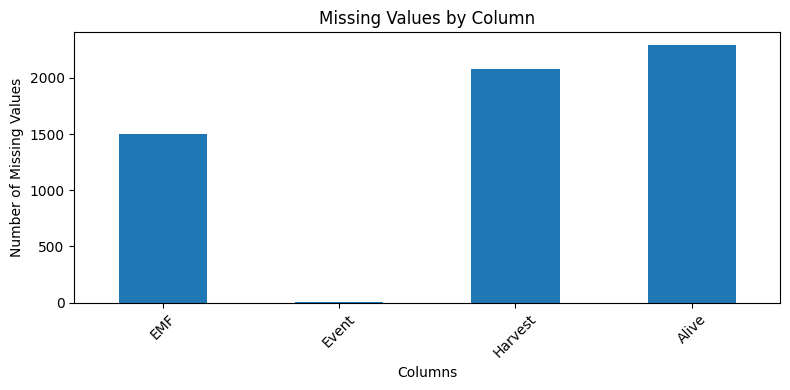

In [ ]:
# Cell 8: Missing Value Visualization

# Visualize missing values in the dataset

missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]

print("Columns with Missing Values:")
print(missing_values)

if len(missing_values) > 0:
    plt.figure(figsize=(8, 4))
    missing_values.plot(kind="bar")

    plt.title("Missing Values by Column")
    plt.xlabel("Columns")
    plt.ylabel("Number of Missing Values")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")

In [ ]:
# Cell 9: Descriptive Analysis of Numerical Features

# Descriptive statistics help us understand numerical columns
# count, mean, standard deviation, min, max, etc.

numerical_data = df.select_dtypes(include=["int64", "float64"])

display(numerical_data.describe().T)

,count,mean,std,min,25%,50%,75%,max
No,2783.0,3914.513834,2253.515063,3.000,1971.000,3932.000,5879.000,7772.000
Plot,2783.0,9.561624,5.203659,1.000,5.000,10.000,14.000,18.000
Light_ISF,2783.0,0.085707,0.025638,0.032,0.066,0.082,0.100,0.161
Core,2783.0,2016.648940,0.477387,2016.000,2016.000,2017.000,2017.000,2017.000
AMF,2783.0,20.553069,12.309587,0.000,13.400,18.000,24.445,100.000
EMF,1283.0,26.476750,16.636890,0.000,13.780,27.720,35.710,87.500
Phenolics,2783.0,1.933105,1.969842,-1.350,0.170,0.750,3.780,6.100
Lignin,2783.0,15.759792,6.779607,2.230,10.355,14.040,21.115,32.770
NSC,2783.0,14.219641,4.298271,4.300,11.605,12.660,17.275,29.450
Census,2783.0,15.282070,9.166555,4.000,7.000,13.000,18.000,33.000


In [ ]:
# Cell 10: Descriptive Analysis of Categorical Features

# Categorical summary shows count, unique values, top value, and frequency

categorical_data = df.select_dtypes(include=["object"])

display(categorical_data.describe().T)

,count,unique,top,freq
Subplot,2783,5,A,701
Species,2783,4,Acer saccharum,751
Light_Cat,2783,3,Med,1474
Soil,2783,7,Sterile,423
Adult,2783,36,I,90
Sterile,2783,2,Non-Sterile,2360
Conspecific,2783,3,Heterospecific,1974
Myco,2783,2,AMF,1500
SoilMyco,2783,3,AMF,1186
PlantDate,2783,19,6/7/18,340


In [ ]:
# Cell 11: Variance and Skewness of Numerical Features

# Variance shows how spread out the values are
# Skewness shows whether the data is tilted to one side

print("Variance of Numerical Features:")
display(numerical_data.var())

print("\nSkewness of Numerical Features:")
display(numerical_data.skew())

Variance of Numerical Features:


,0
No,5.078330e+06
Plot,2.707807e+01
Light_ISF,6.572914e-04
Core,2.278988e-01
AMF,1.515259e+02
EMF,2.767861e+02
Phenolics,3.880277e+00
Lignin,4.596307e+01
NSC,1.847513e+01
Census,8.402573e+01



Skewness of Numerical Features:


,0
No,-0.013436
Plot,-0.012063
Light_ISF,0.658495
Core,-0.624428
AMF,1.530073
EMF,0.504768
Phenolics,0.325592
Lignin,0.141701
NSC,0.569887
Census,1.033268


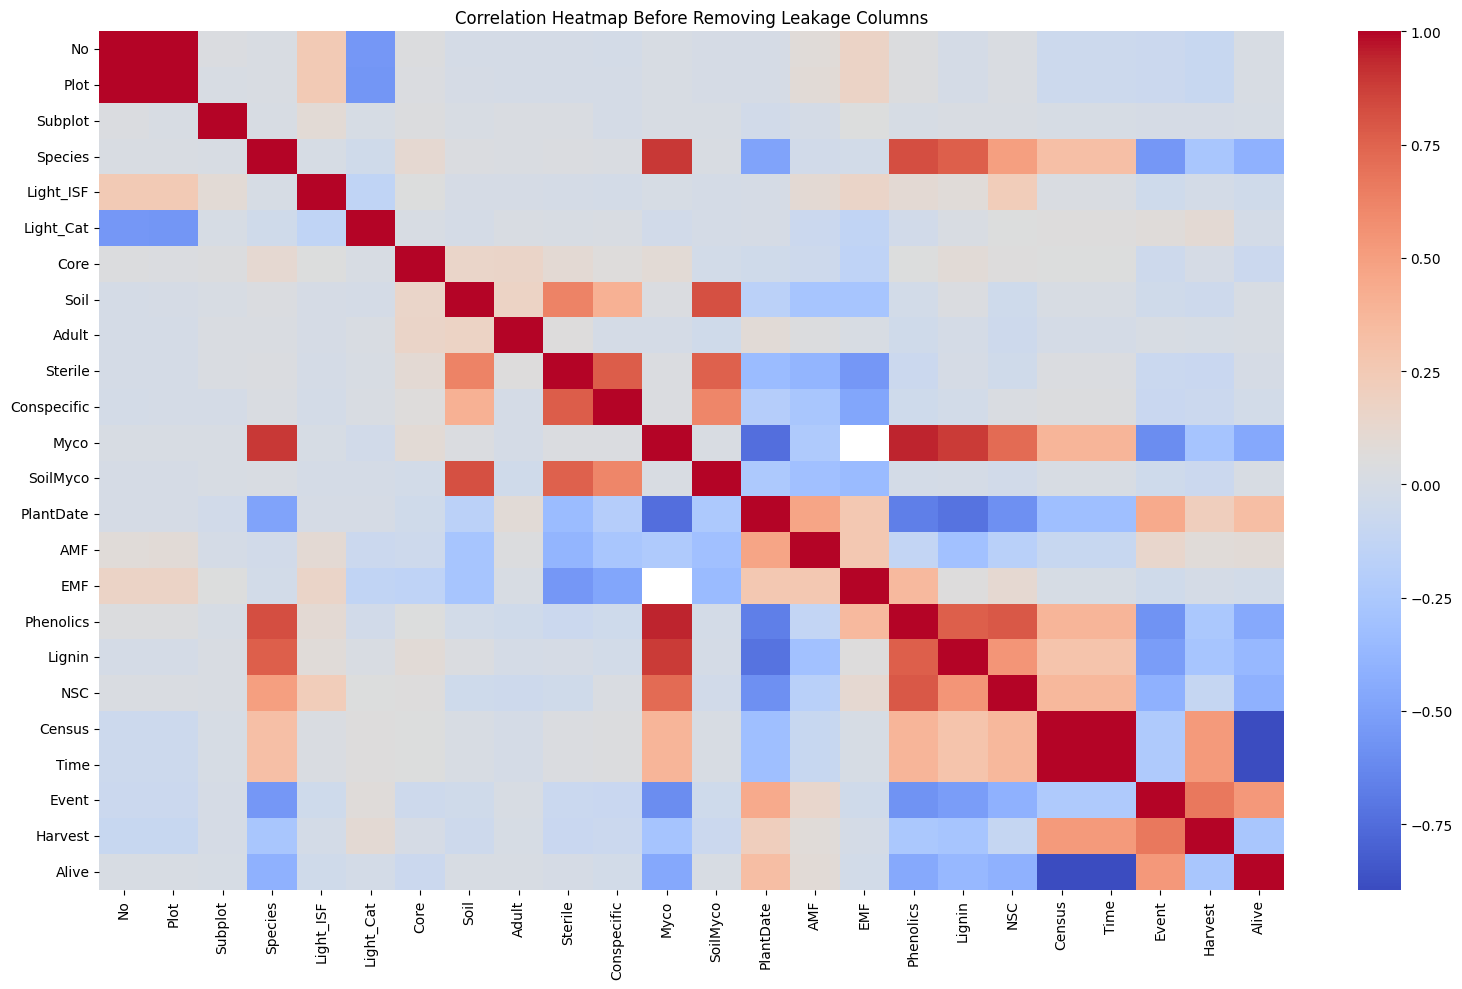

In [ ]:
# Cell 12: Correlation Heatmap Before Removing Leakage Columns

# Correlation heatmap shows relationships between features
# Since some columns are text, we temporarily encode them only for correlation checking

df_corr = df.copy()
temp_encoder = LabelEncoder()

for col in df_corr.select_dtypes(include=["object"]).columns:
    df_corr[col] = df_corr[col].astype(str)
    df_corr[col] = temp_encoder.fit_transform(df_corr[col])

plt.figure(figsize=(16, 10))
sns.heatmap(df_corr.corr(), cmap="coolwarm", annot=False)

plt.title("Correlation Heatmap Before Removing Leakage Columns")
plt.tight_layout()
plt.show()

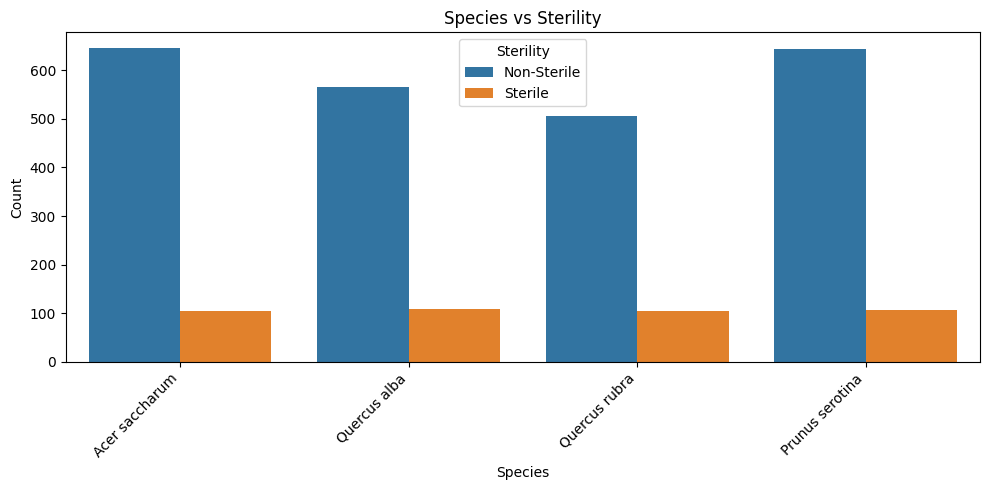

In [ ]:
# Cell 13: EDA Plot - Species vs Sterility

# This plot checks whether sterility differs by species

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="Species", hue=target_column)

plt.title("Species vs Sterility")
plt.xlabel("Species")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Sterility")
plt.tight_layout()
plt.show()

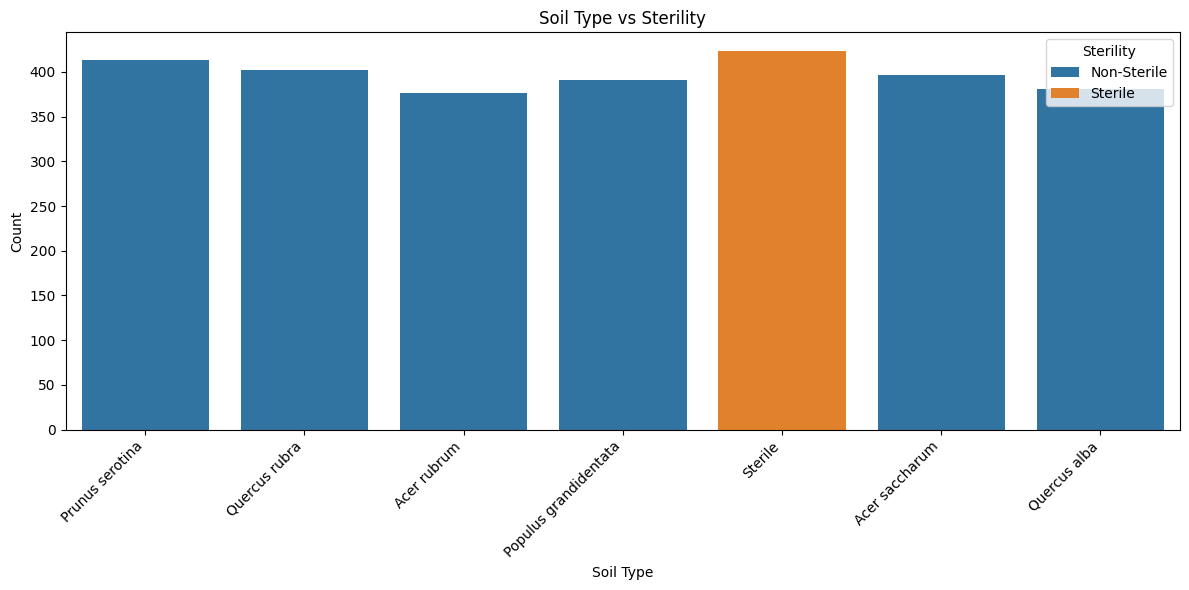

In [ ]:
# Cell 14: EDA Plot - Soil vs Sterility

# This plot helps us detect leakage
# Soil is later removed because it directly reveals the target too much

plt.figure(figsize=(12, 6))
sns.countplot(data=df, x="Soil", hue=target_column)

plt.title("Soil Type vs Sterility")
plt.xlabel("Soil Type")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Sterility")
plt.tight_layout()
plt.show()

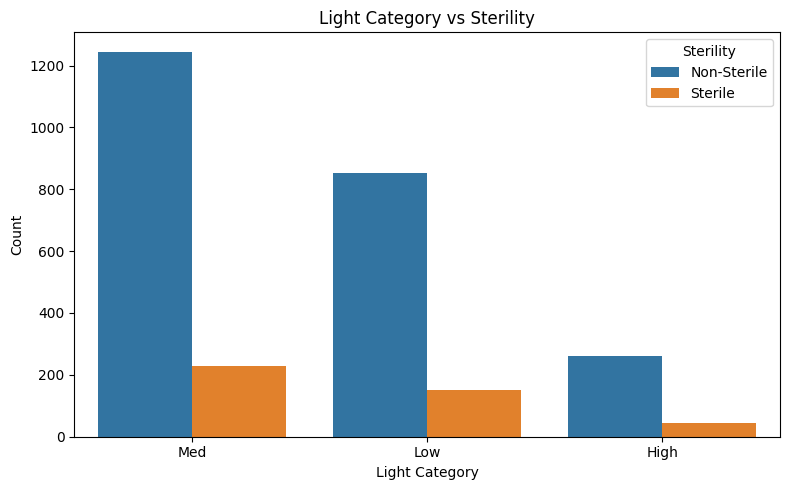

In [ ]:
# Cell 15: EDA Plot - Light Category vs Sterility

# This plot checks the relationship between light category and sterility

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Light_Cat", hue=target_column)

plt.title("Light Category vs Sterility")
plt.xlabel("Light Category")
plt.ylabel("Count")
plt.legend(title="Sterility")
plt.tight_layout()
plt.show()

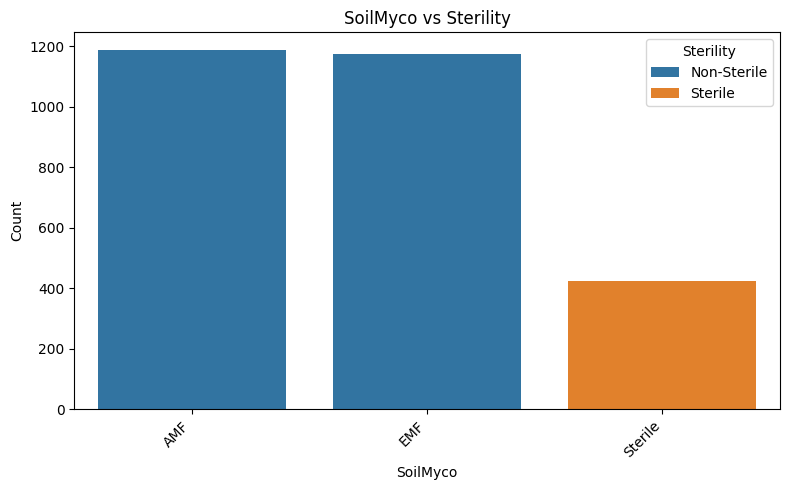

In [ ]:
# Cell 16: EDA Plot - SoilMyco vs Sterility

# This plot also helps identify leakage
# SoilMyco is later removed before model training

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="SoilMyco", hue=target_column)

plt.title("SoilMyco vs Sterility")
plt.xlabel("SoilMyco")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Sterility")
plt.tight_layout()
plt.show()

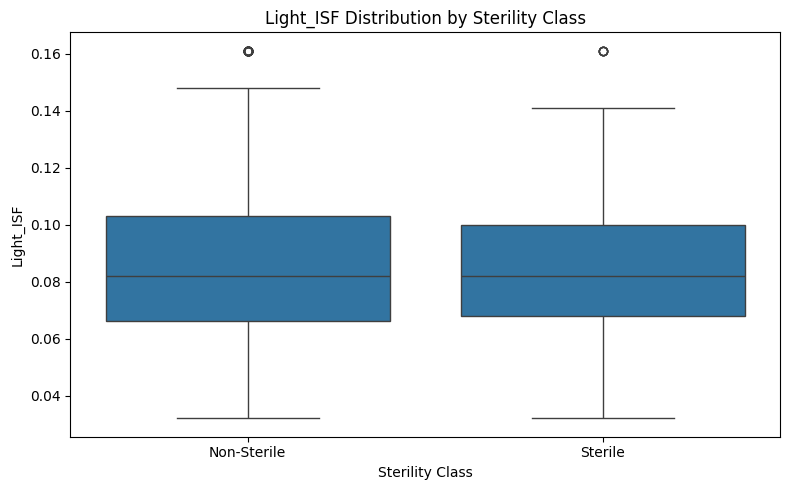

In [ ]:
# Cell 17: EDA Plot - Light_ISF vs Sterility

# Boxplot shows how a numerical feature differs between target classes

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x=target_column, y="Light_ISF")

plt.title("Light_ISF Distribution by Sterility Class")
plt.xlabel("Sterility Class")
plt.ylabel("Light_ISF")
plt.tight_layout()
plt.show()

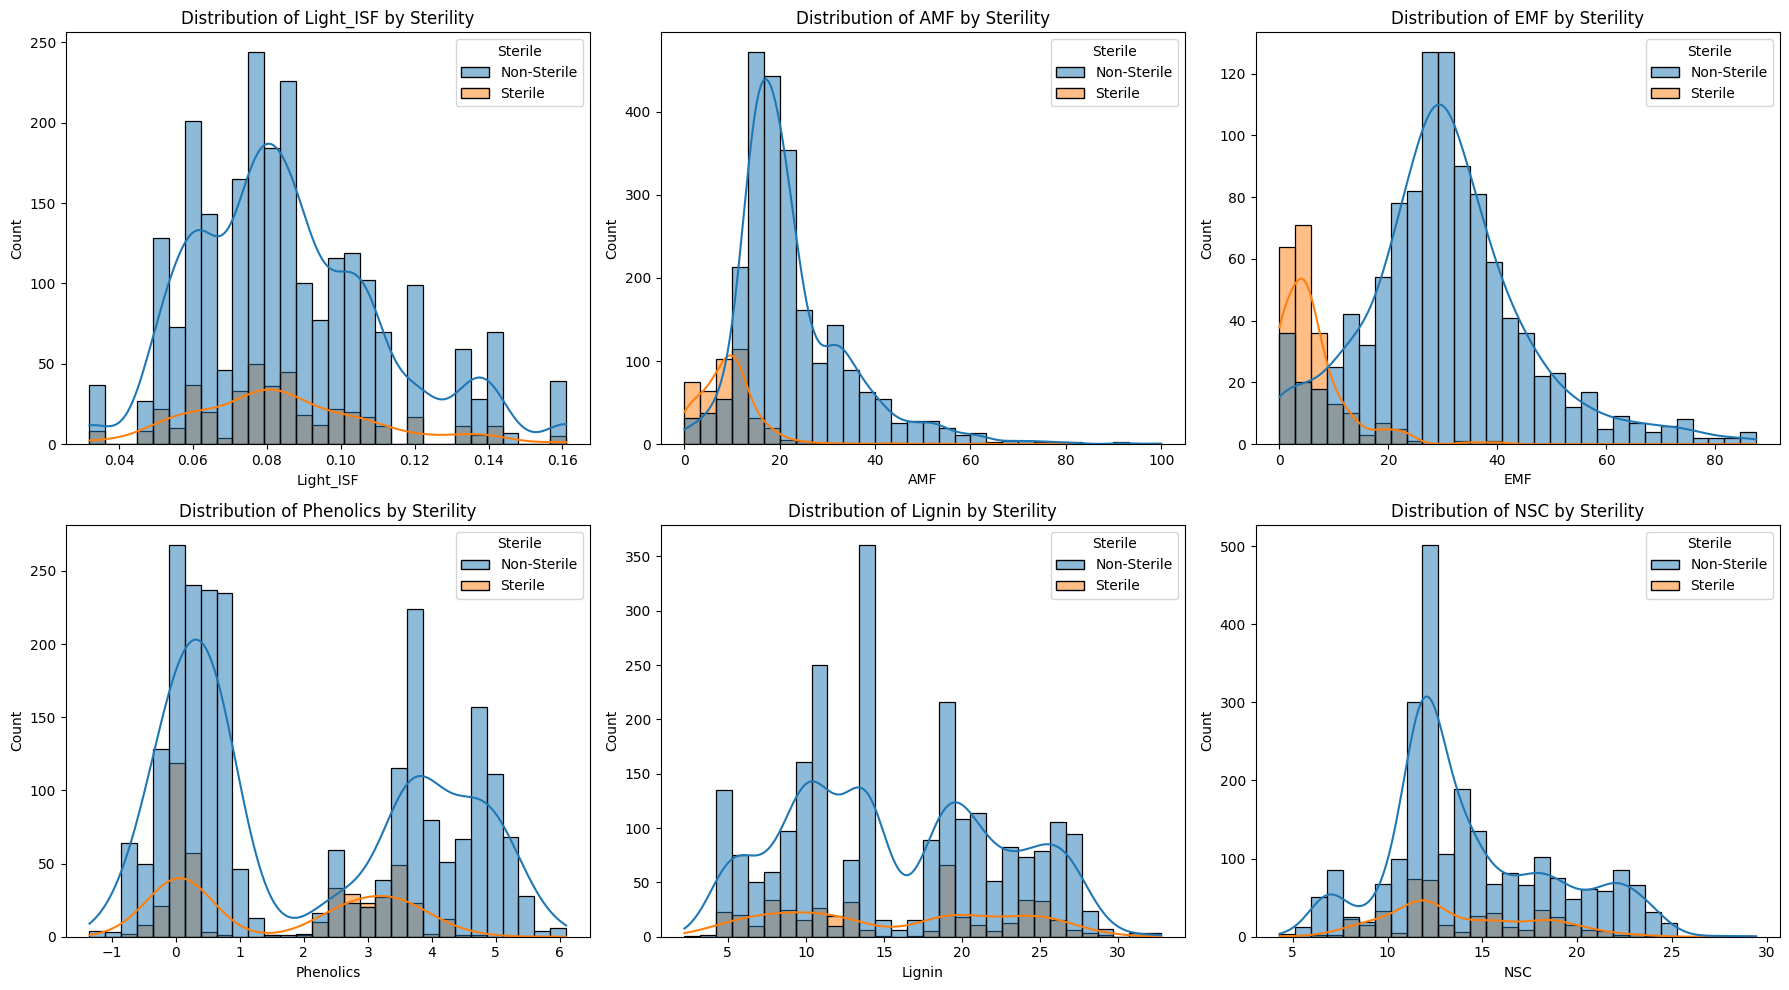

In [ ]:
# Cell 18: Feature Distribution Plots by Sterility Class

# These plots show the distribution of important numerical features

numeric_eda_cols = ["Light_ISF", "AMF", "EMF", "Phenolics", "Lignin", "NSC"]
numeric_eda_cols = [col for col in numeric_eda_cols if col in df.columns]

rows = math.ceil(len(numeric_eda_cols) / 3)
fig, axes = plt.subplots(rows, 3, figsize=(18, 5 * rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(numeric_eda_cols):
    sns.histplot(
        data=df,
        x=col,
        hue=target_column,
        kde=True,
        bins=30,
        ax=axes[i]
    )
    axes[i].set_title(f"Distribution of {col} by Sterility")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

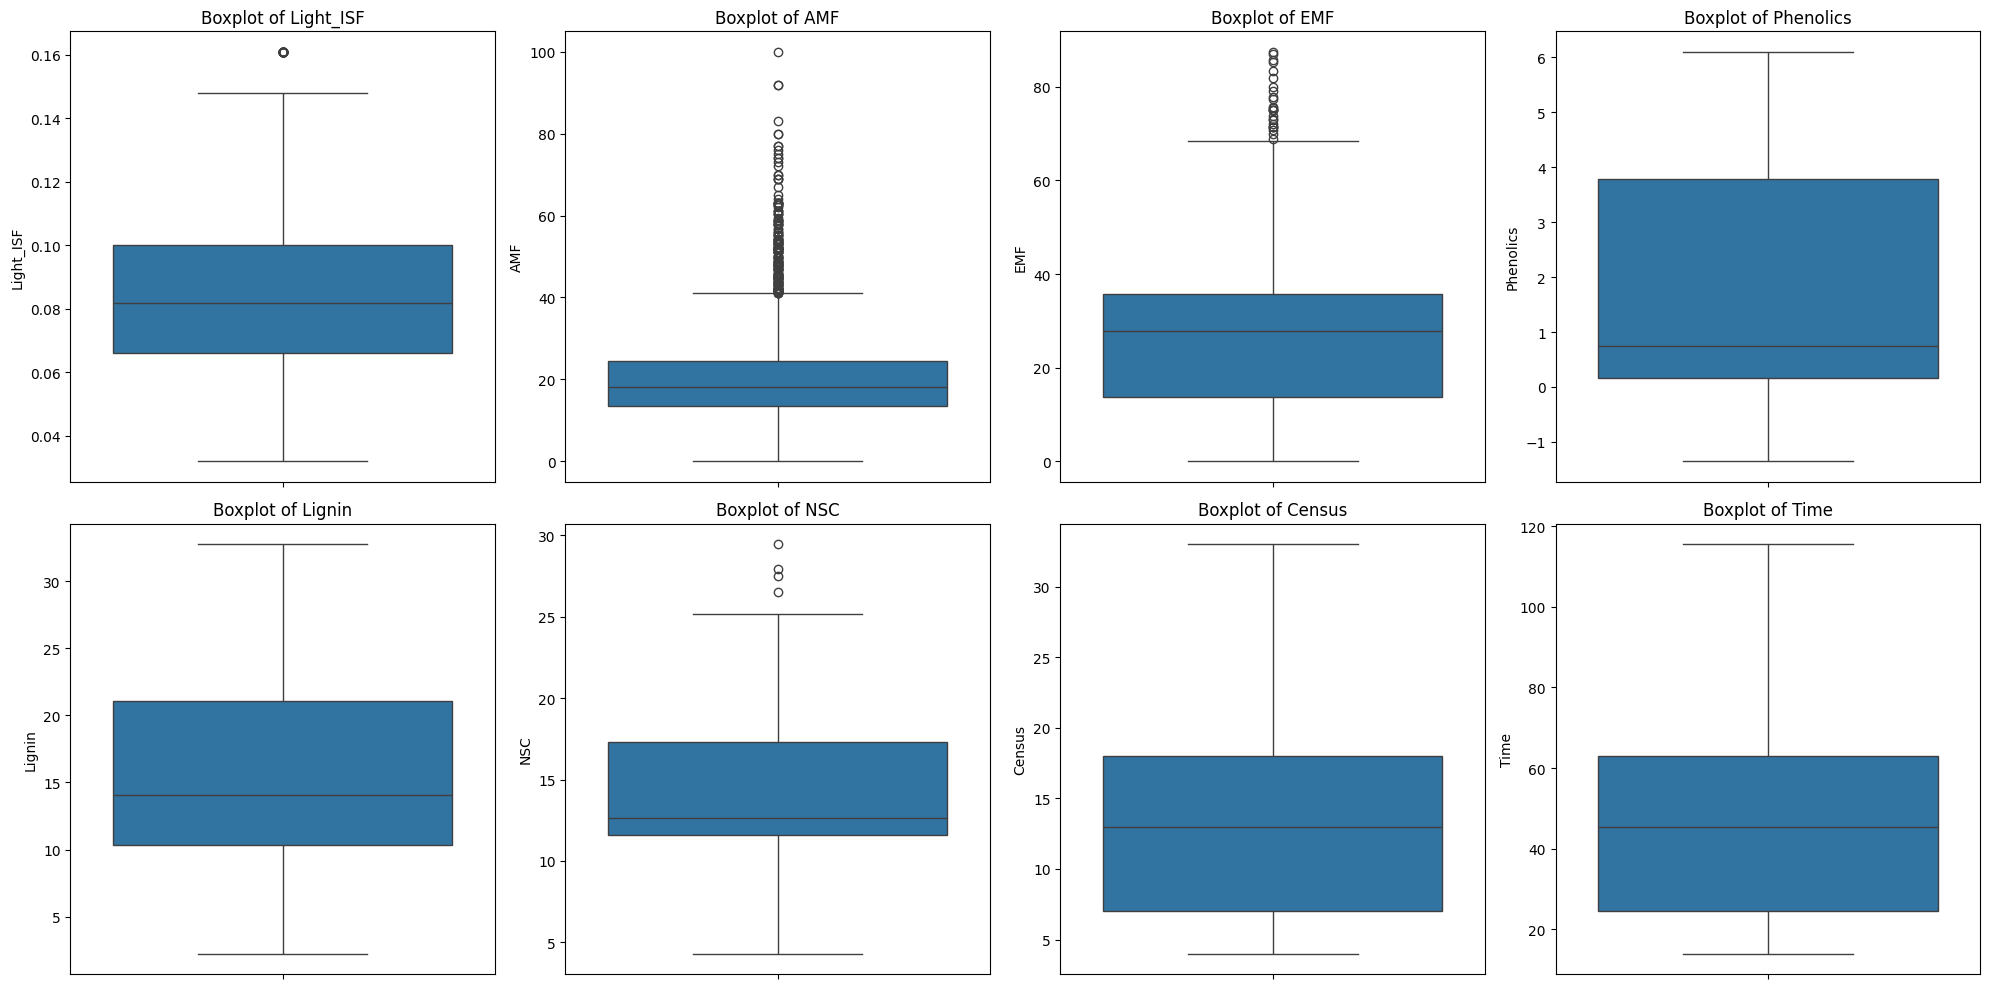

In [ ]:
# Cell 19: Boxplots for Numerical Features

# Boxplots show spread, median, and outliers for numerical columns

boxplot_cols = ["Light_ISF", "AMF", "EMF", "Phenolics", "Lignin", "NSC", "Census", "Time"]
boxplot_cols = [col for col in boxplot_cols if col in df.columns]

rows = math.ceil(len(boxplot_cols) / 4)
fig, axes = plt.subplots(rows, 4, figsize=(20, 5 * rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(boxplot_cols):
    sns.boxplot(data=df, y=col, ax=axes[i])
    axes[i].set_title(f"Boxplot of {col}")
    axes[i].set_ylabel(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

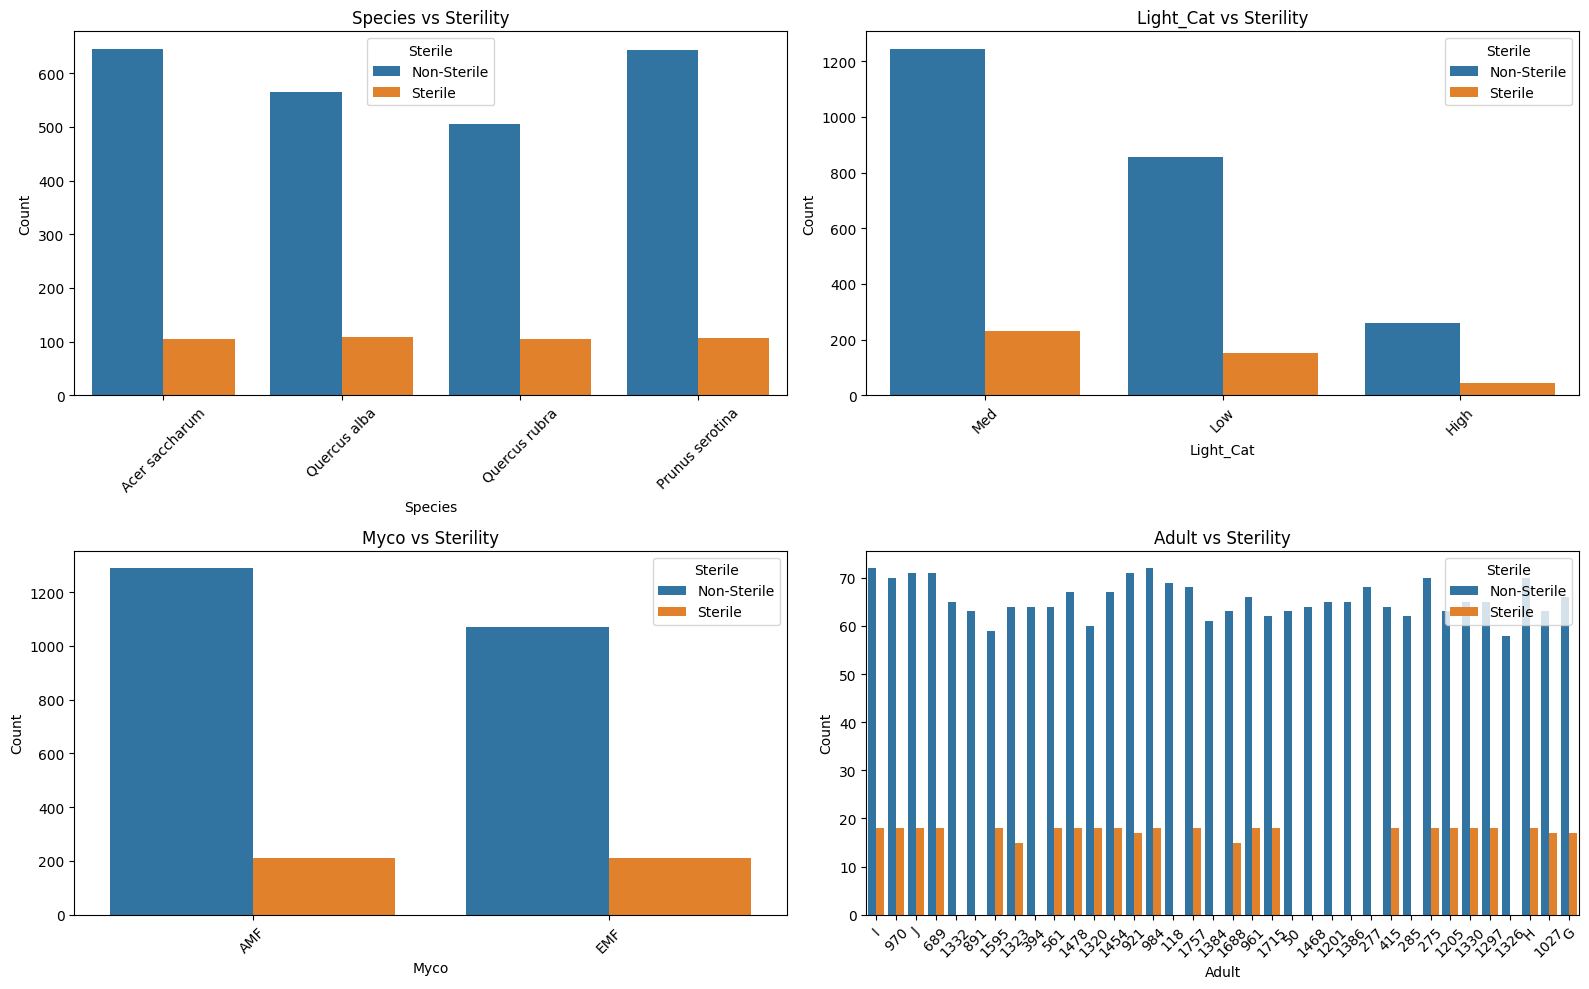

In [ ]:
# Cell 20: Categorical Feature Comparison

# This compares some important categorical features with the target

cat_plot_cols = ["Species", "Light_Cat", "Myco", "Adult"]
cat_plot_cols = [col for col in cat_plot_cols if col in df.columns]

rows = math.ceil(len(cat_plot_cols) / 2)
fig, axes = plt.subplots(rows, 2, figsize=(16, 5 * rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(cat_plot_cols):
    sns.countplot(data=df, x=col, hue=target_column, ax=axes[i])
    axes[i].set_title(f"{col} vs Sterility")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=45)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
# Cell 21: Drop Unnecessary and Leakage Columns

# Some columns are removed before training:
# No = ID column
# PlantDate = date column, not directly used
# Harvest and Alive = many missing values
# Soil, Conspecific, SoilMyco = leakage columns because they reveal the target too much

drop_columns = [
    "No",
    "PlantDate",
    "Harvest",
    "Alive",
    "Soil",
    "Conspecific",
    "SoilMyco"
]

df_model = df.drop(columns=drop_columns)

print("Original shape:", df.shape)
print("Shape after dropping unnecessary/leakage columns:", df_model.shape)

df_model.head()

Original shape: (2783, 24)
Shape after dropping unnecessary/leakage columns: (2783, 17)


,Plot,Subplot,Species,Light_ISF,Light_Cat,Core,Adult,Sterile,Myco,AMF,EMF,Phenolics,Lignin,NSC,Census,Time,Event
0,1,C,Acer saccharum,0.106,Med,2017,I,Non-Sterile,AMF,22.00,NaN,-0.56,13.86,12.15,4,14.0,1.0
1,1,C,Quercus alba,0.106,Med,2017,970,Non-Sterile,EMF,15.82,31.07,5.19,20.52,19.29,33,115.5,0.0
2,1,C,Quercus rubra,0.106,Med,2017,J,Non-Sterile,EMF,24.45,28.19,3.36,24.74,15.01,18,63.0,1.0
3,7,D,Acer saccharum,0.080,Med,2016,J,Non-Sterile,AMF,22.23,NaN,-0.71,14.29,12.36,4,14.0,1.0
4,14,A,Acer saccharum,0.060,Low,2017,689,Non-Sterile,AMF,21.15,NaN,-0.58,10.85,11.20,4,14.0,1.0


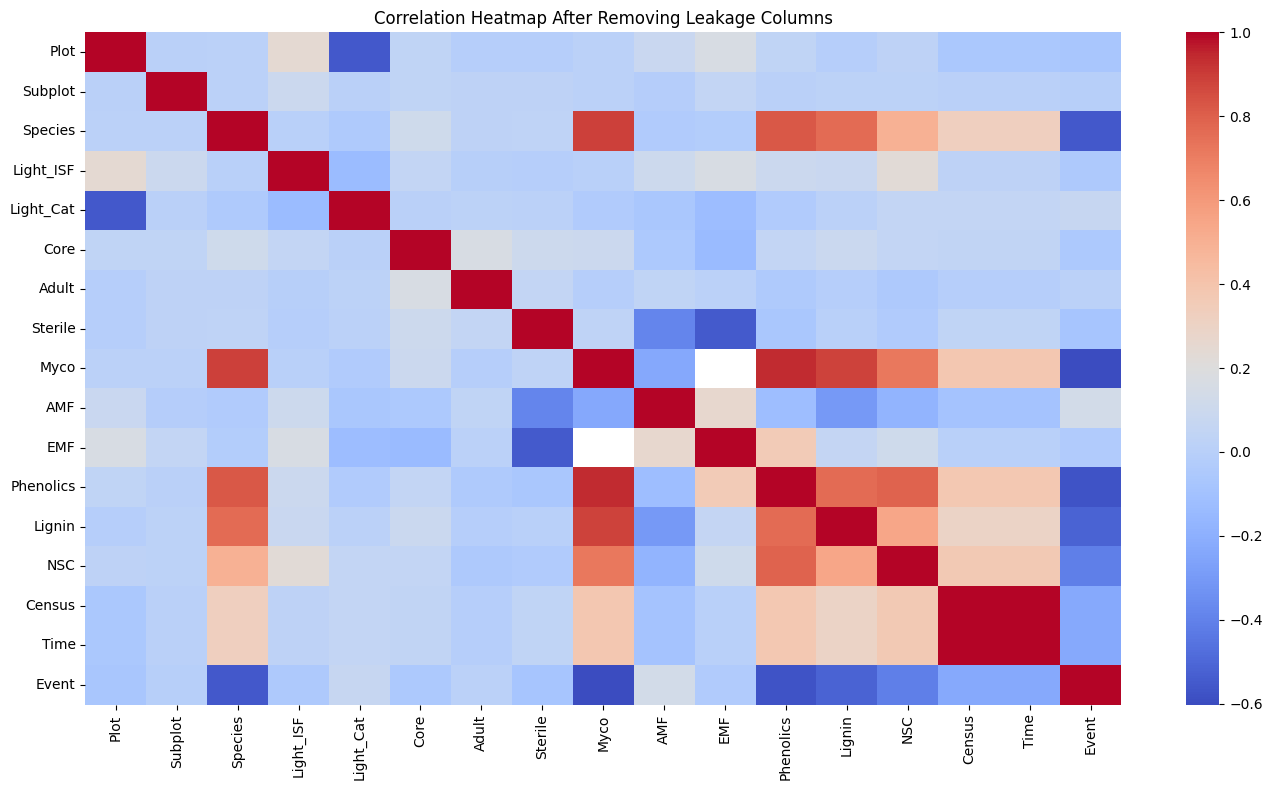

In [ ]:
# Cell 22: Correlation Heatmap After Removing Leakage Columns

# This is the cleaner correlation heatmap after removing leakage columns

df_model_corr = df_model.copy()
temp_encoder = LabelEncoder()

for col in df_model_corr.select_dtypes(include=["object"]).columns:
    df_model_corr[col] = df_model_corr[col].astype(str)
    df_model_corr[col] = temp_encoder.fit_transform(df_model_corr[col])

plt.figure(figsize=(14, 8))
sns.heatmap(df_model_corr.corr(), cmap="coolwarm", annot=False)

plt.title("Correlation Heatmap After Removing Leakage Columns")
plt.tight_layout()
plt.show()

In [ ]:
# Cell 23: Separate Input Features and Target

# X contains input features
# y contains the target/output column

X = df_model.drop(columns=[target_column])
y = df_model[target_column]

print("Input Features Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nInput Columns:")
print(X.columns.tolist())

Input Features Shape: (2783, 16)
Target Shape: (2783,)

Input Columns:
['Plot', 'Subplot', 'Species', 'Light_ISF', 'Light_Cat', 'Core', 'Adult', 'Myco', 'AMF', 'EMF', 'Phenolics', 'Lignin', 'NSC', 'Census', 'Time', 'Event']


In [ ]:
# Cell 24: Encode Target Variable

# Convert target classes into numbers
# Example: Non-Sterile = 0, Sterile = 1

target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)

print("Original Target Classes:")
print(target_encoder.classes_)

print("\nEncoded Target Values:")
print(np.unique(y_encoded))

target_mapping = dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_)))
print("\nTarget Mapping:")
print(target_mapping)

Original Target Classes:
['Non-Sterile' 'Sterile']

Encoded Target Values:
[0 1]

Target Mapping:
{'Non-Sterile': np.int64(0), 'Sterile': np.int64(1)}


In [ ]:
# Cell 25: Identify Input Feature Types

# Identify categorical and numerical input features after dropping columns

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

print("\nNumber of Categorical Features:", len(categorical_features))
print("Number of Numerical Features:", len(numerical_features))

Categorical Features:
['Subplot', 'Species', 'Light_Cat', 'Adult', 'Myco']

Numerical Features:
['Plot', 'Light_ISF', 'Core', 'AMF', 'EMF', 'Phenolics', 'Lignin', 'NSC', 'Census', 'Time', 'Event']

Number of Categorical Features: 5
Number of Numerical Features: 11


In [ ]:
# Cell 26: Train/Validation/Test Split

# Faculty asked for Train/Val/Test split
# Final split:
# 70% training
# 10% validation
# 20% testing

# First split: 80% train+validation, 20% test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

# Second split: from the 80%, create 70% train and 10% validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.125,
    random_state=42,
    stratify=y_train_val
)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

print("\nTraining target distribution:")
print(pd.Series(y_train).value_counts())

print("\nValidation target distribution:")
print(pd.Series(y_val).value_counts())

print("\nTesting target distribution:")
print(pd.Series(y_test).value_counts())

X_train shape: (1947, 16)
X_val shape: (279, 16)
X_test shape: (557, 16)

Training target distribution:
0    1651
1     296
Name: count, dtype: int64

Validation target distribution:
0    237
1     42
Name: count, dtype: int64

Testing target distribution:
0    472
1     85
Name: count, dtype: int64


In [ ]:
# Cell 27: Create Preprocessing Pipeline

# Preprocessing means cleaning data before model training
# Numerical columns: missing values filled with median, then scaled
# Categorical columns: missing values filled with most frequent value, then one-hot encoded

try:
    onehot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", onehot_encoder)
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [ ]:
# Cell 28: Fit Preprocessor on Training Data Only

# Very important:
# We fit preprocessing only on training data to avoid data leakage
# Then we transform validation and test data using the same fitted preprocessor

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("Processed Training Shape:", X_train_processed.shape)
print("Processed Validation Shape:", X_val_processed.shape)
print("Processed Testing Shape:", X_test_processed.shape)

Processed Training Shape: (1947, 61)
Processed Validation Shape: (279, 61)
Processed Testing Shape: (557, 61)


Best K: 3
Best Validation Accuracy for KNN: 0.9283154121863799


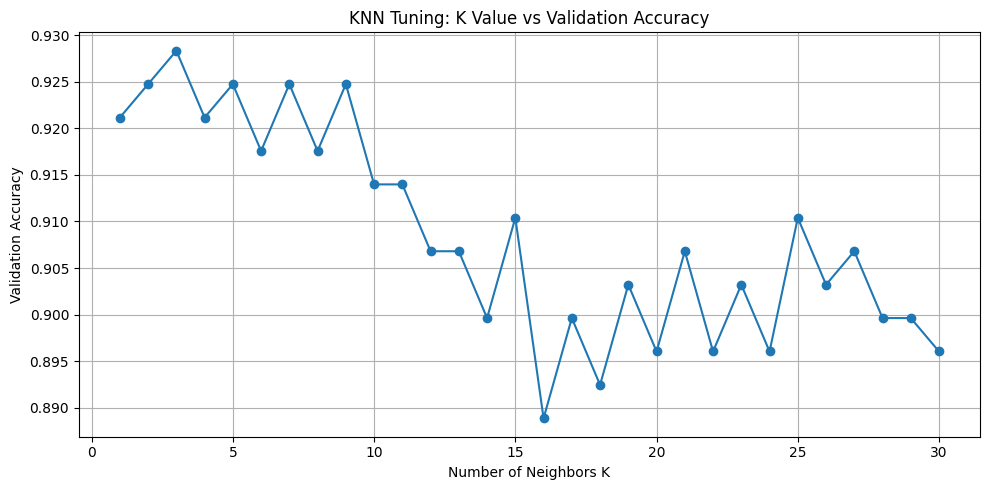

In [ ]:
# Cell 29: KNN Tuning Using Validation Set

# This checks different K values for KNN
# We choose the K value that gives the best validation accuracy

k_values = range(1, 31)
knn_validation_scores = []

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_processed, y_train)

    y_val_pred = knn_temp.predict(X_val_processed)
    val_acc = accuracy_score(y_val, y_val_pred)

    knn_validation_scores.append(val_acc)

best_k = list(k_values)[np.argmax(knn_validation_scores)]
best_knn_score = max(knn_validation_scores)

print("Best K:", best_k)
print("Best Validation Accuracy for KNN:", best_knn_score)

plt.figure(figsize=(10, 5))
plt.plot(k_values, knn_validation_scores, marker="o")
plt.title("KNN Tuning: K Value vs Validation Accuracy")
plt.xlabel("Number of Neighbors K")
plt.ylabel("Validation Accuracy")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Cell 30: Define Supervised Models

# We train 5 supervised models
# Neural Network is mandatory
# Other models are used for comparison

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced",
        max_depth=8
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=best_k
    ),

    "Naive Bayes": GaussianNB(),

    "Neural Network": MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        max_iter=500,
        random_state=42,
        early_stopping=True
    )
}

print("Models created successfully.")

Models created successfully.


In [ ]:
# Cell 31: Train Models and Evaluate on Test Set

# Train each model on training data
# Then test each model on testing data

results = []
trained_models = {}

for model_name, model in models.items():
    print("=" * 70)
    print("Training Model:", model_name)
    print("=" * 70)

    # Train model
    model.fit(X_train_processed, y_train)

    # Store trained model
    trained_models[model_name] = model

    # Predict test data
    y_pred = model.predict(X_test_processed)

    # Calculate evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    # Calculate AUC if model supports predict_proba
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_processed)[:, 1]
        auc = roc_auc_score(y_test, y_prob)
    else:
        auc = np.nan

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "AUC Score": auc
    })

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=target_encoder.classes_, zero_division=0))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\n")

Training Model: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

 Non-Sterile       0.99      0.93      0.96       472
     Sterile       0.70      0.95      0.81        85

    accuracy                           0.93       557
   macro avg       0.85      0.94      0.88       557
weighted avg       0.95      0.93      0.94       557


Confusion Matrix:
[[438  34]
 [  4  81]]


Training Model: Decision Tree

Classification Report:
              precision    recall  f1-score   support

 Non-Sterile       0.99      0.95      0.97       472
     Sterile       0.76      0.94      0.84        85

    accuracy                           0.95       557
   macro avg       0.88      0.94      0.90       557
weighted avg       0.95      0.95      0.95       557


Confusion Matrix:
[[447  25]
 [  5  80]]


Training Model: KNN

Classification Report:
              precision    recall  f1-score   support

 Non-Sterile       0.96      0.98      0.97  

In [ ]:
# Cell 32: Validation Performance

# This shows how the models perform on validation data

validation_results = []

for model_name, model in trained_models.items():
    y_val_pred = model.predict(X_val_processed)

    val_accuracy = accuracy_score(y_val, y_val_pred)
    val_precision = precision_score(y_val, y_val_pred, average="weighted", zero_division=0)
    val_recall = recall_score(y_val, y_val_pred, average="weighted", zero_division=0)
    val_f1 = f1_score(y_val, y_val_pred, average="weighted", zero_division=0)

    validation_results.append({
        "Model": model_name,
        "Validation Accuracy": val_accuracy,
        "Validation Precision": val_precision,
        "Validation Recall": val_recall,
        "Validation F1 Score": val_f1
    })

validation_results_df = pd.DataFrame(validation_results)
display(validation_results_df)

,Model,Validation Accuracy,Validation Precision,Validation Recall,Validation F1 Score
0,Logistic Regression,0.935484,0.949371,0.935484,0.939110
1,Decision Tree,0.935484,0.949371,0.935484,0.939110
2,KNN,0.928315,0.924892,0.928315,0.924212
3,Naive Bayes,0.451613,0.881886,0.451613,0.497934
4,Neural Network,0.953405,0.952134,0.953405,0.952174


In [ ]:
# Cell 33: Test Result Table

# Show final test performance of all models

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Accuracy", ascending=False)

display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score,AUC Score
4,Neural Network,0.965889,0.965296,0.965889,0.965096,0.971510
2,KNN,0.947935,0.946351,0.947935,0.946434,0.942822
1,Decision Tree,0.946140,0.954292,0.946140,0.948392,0.940055
0,Logistic Regression,0.931777,0.947214,0.931777,0.935774,0.966750
3,Naive Bayes,0.418312,0.879111,0.418312,0.457079,0.656780


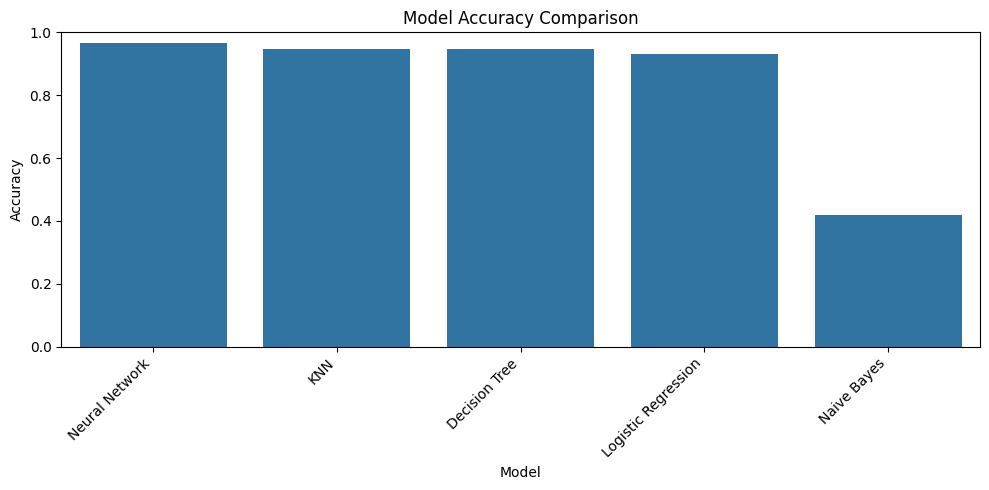

In [ ]:
# Cell 34: Accuracy Comparison Bar Chart

# Compare model accuracy using a bar chart

plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="Model", y="Accuracy")

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

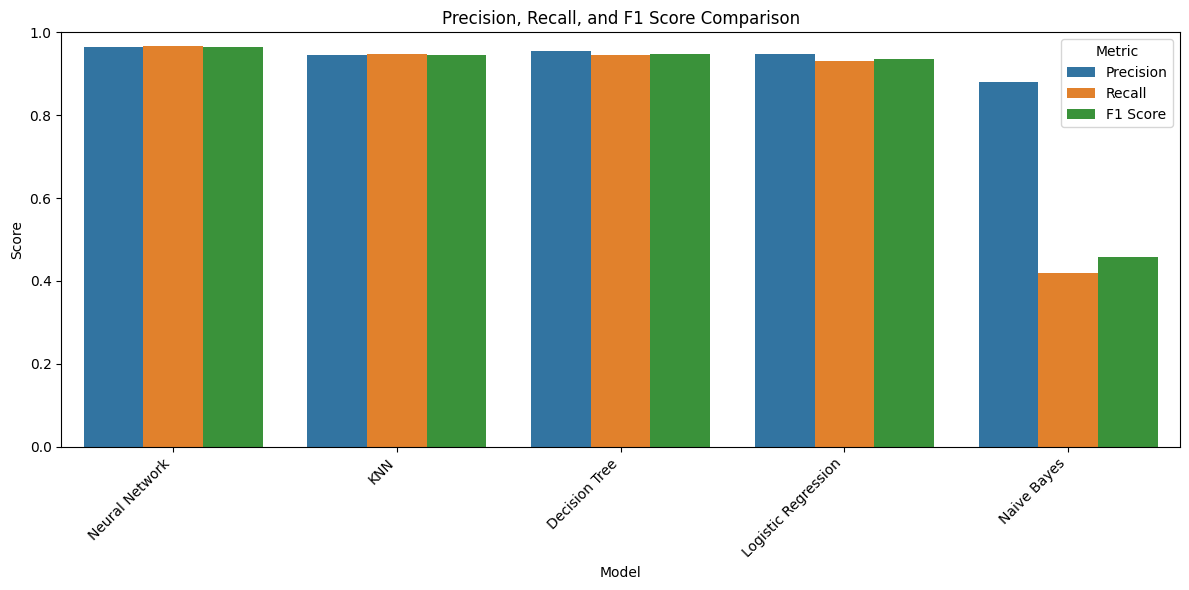

In [ ]:
# Cell 35: Precision, Recall, and F1 Comparison

# Precision, recall, and F1-score are important because the dataset is imbalanced

metrics_df = results_df.melt(
    id_vars="Model",
    value_vars=["Precision", "Recall", "F1 Score"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))
sns.barplot(data=metrics_df, x="Model", y="Score", hue="Metric")

plt.title("Precision, Recall, and F1 Score Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

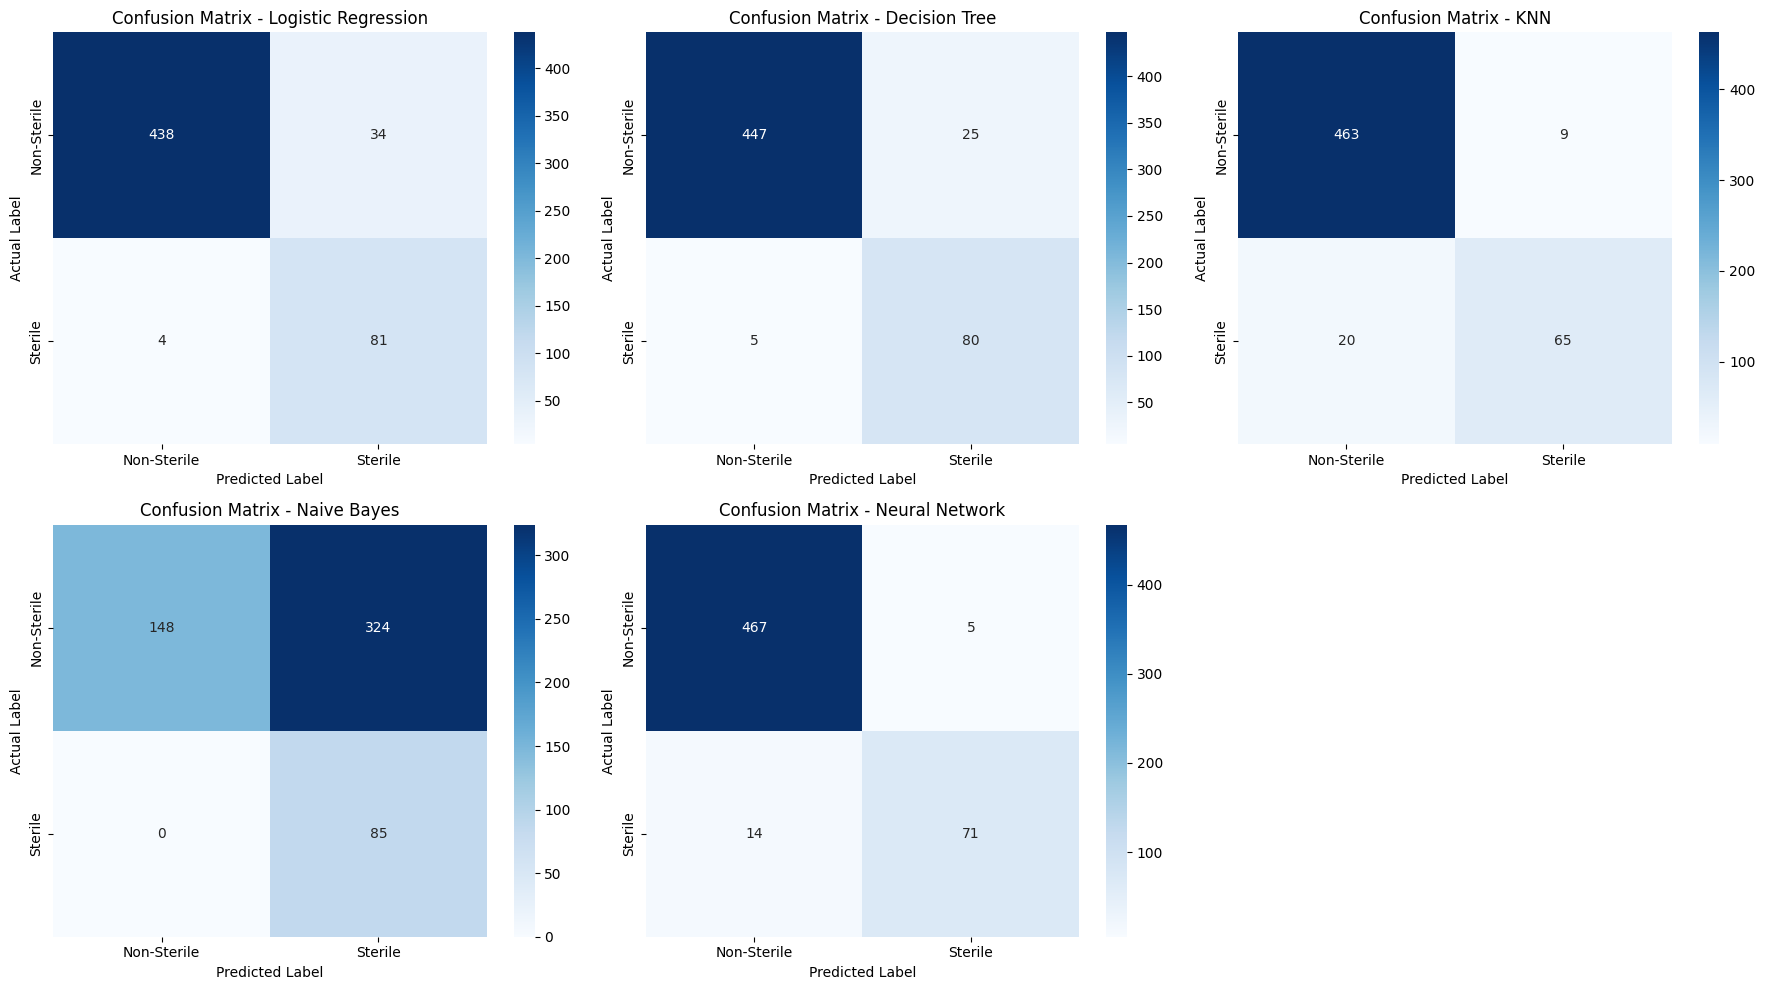

In [ ]:
# Cell 36: Confusion Matrices Side by Side

# Confusion matrix shows correct and incorrect predictions for each class

model_items = list(trained_models.items())
cols = 3
rows = math.ceil(len(model_items) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, 10))
axes = np.array(axes).reshape(-1)

for i, (model_name, model) in enumerate(model_items):
    y_pred = model.predict(X_test_processed)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=target_encoder.classes_,
        yticklabels=target_encoder.classes_,
        ax=axes[i]
    )

    axes[i].set_title(f"Confusion Matrix - {model_name}")
    axes[i].set_xlabel("Predicted Label")
    axes[i].set_ylabel("Actual Label")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

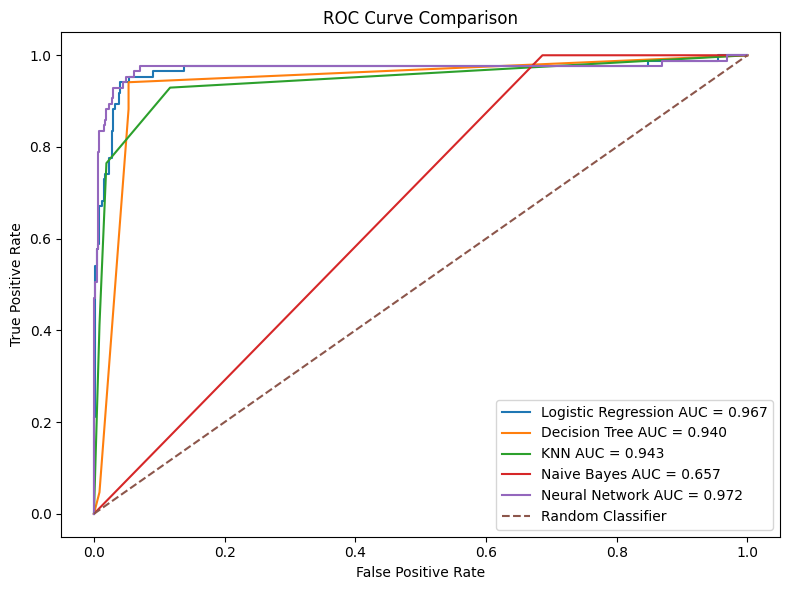

In [ ]:
# Cell 37: ROC Curve and AUC Score

# ROC curve shows how well models separate the two classes
# AUC closer to 1 means better model

plt.figure(figsize=(8, 6))

for model_name, model in trained_models.items():
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_processed)[:, 1]
        fpr, tpr, thresholds = roc_curve(y_test, y_prob)
        auc_score = roc_auc_score(y_test, y_prob)

        plt.plot(fpr, tpr, label=f"{model_name} AUC = {auc_score:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Cell 38: Best Model

# Find the best model based on accuracy

best_model = results_df.iloc[0]

print("Best Performing Model:")
print(best_model)

Best Performing Model:
Model        Neural Network
Accuracy           0.965889
Precision          0.965296
Recall             0.965889
F1 Score           0.965096
AUC Score           0.97151
Name: 4, dtype: object


In [ ]:
# Cell 39: Prepare Data for K-Means

# K-Means is unsupervised learning
# It does not use the target column
# For clustering, we preprocess the full input data

X_all_processed = preprocessor.fit_transform(X)

print("Processed Full Dataset Shape:", X_all_processed.shape)

Processed Full Dataset Shape: (2783, 61)


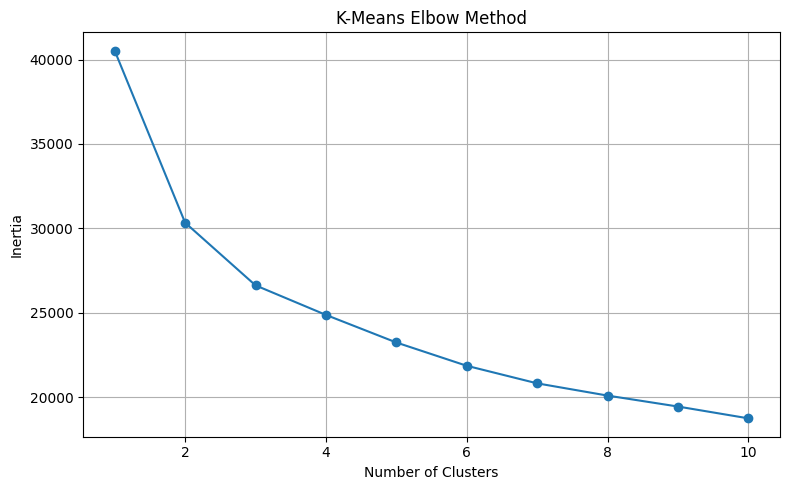

In [ ]:
# Cell 40: K-Means Elbow Method

# Elbow method helps us choose a good number of clusters
# We expect 2 clusters because the target has 2 classes

inertias = []
k_range = range(1, 11)

for k in k_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_all_processed)
    inertias.append(kmeans_temp.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker="o")

plt.title("K-Means Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Cell 41: Apply K-Means Clustering

# Apply K-Means with 2 clusters because the target has 2 classes

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_all_processed)

print("Cluster Labels:")
print(np.unique(clusters))

print("\nCluster Counts:")
print(pd.Series(clusters).value_counts())

Cluster Labels:
[0 1]

Cluster Counts:
1    1500
0    1283
Name: count, dtype: int64


In [ ]:
# Cell 42: K-Means Silhouette Score

# Silhouette score tells how clearly separated the clusters are
# Closer to 1 means better clusters
# Near 0 means overlapping clusters

sil_score = silhouette_score(X_all_processed, clusters)

print("Silhouette Score:", sil_score)

Silhouette Score: 0.24834491550189422


In [ ]:
# Cell 43: Compare K-Means Clusters with Actual Labels

# This compares unsupervised clusters with actual Sterile/Non-Sterile classes

cluster_comparison = pd.crosstab(
    pd.Series(y.values, name="Actual Class"),
    pd.Series(clusters, name="K-Means Cluster")
)

display(cluster_comparison)

K-Means Cluster,0,1
Actual Class,,
Non-Sterile,1071,1289
Sterile,212,211


In [ ]:
# Cell 44: PCA for Cluster Visualization

# PCA reduces many features into 2 dimensions so we can visualize clusters

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_all_processed)

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

Explained Variance Ratio:
[0.28284523 0.10901296]


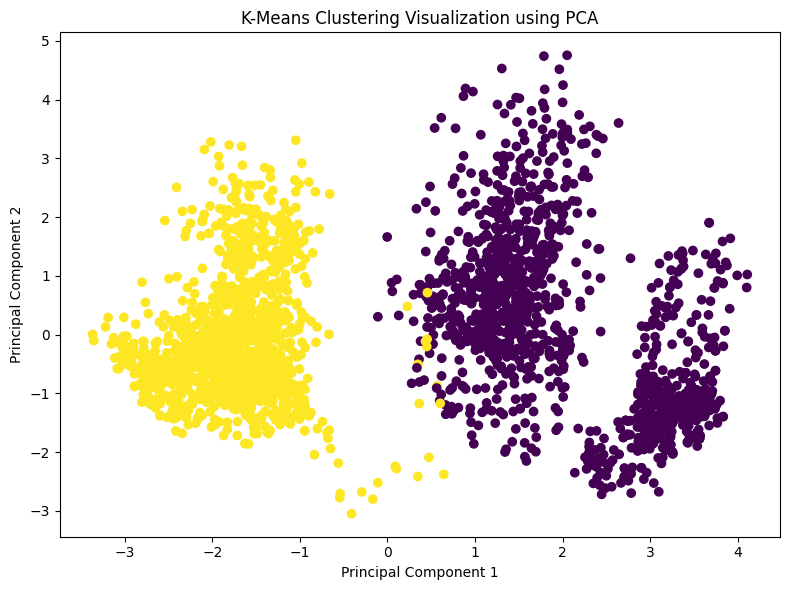

In [ ]:
# Cell 45: K-Means Cluster Visualization

# Visualize K-Means clusters in 2D PCA space

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters)

plt.title("K-Means Clustering Visualization using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.tight_layout()
plt.show()

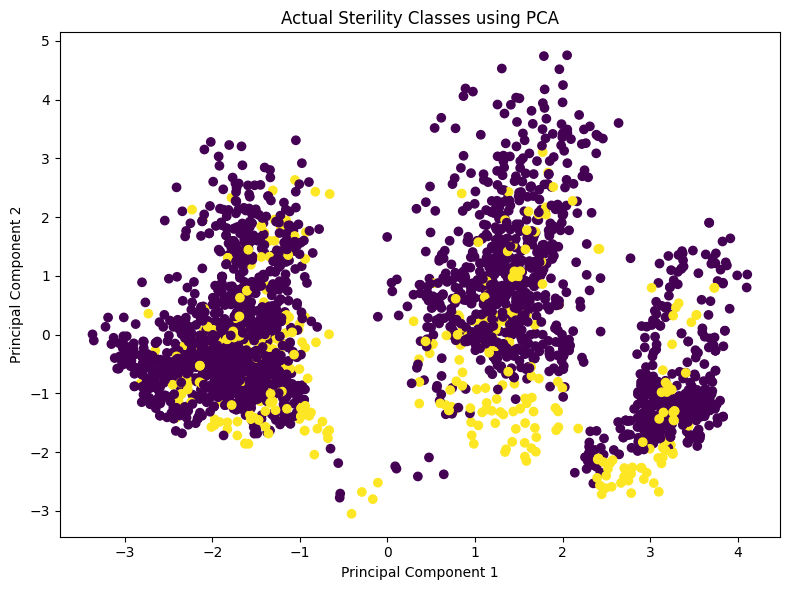

In [ ]:
# Cell 46: Actual Class Visualization with PCA

# Visualize the actual Sterile/Non-Sterile classes in the same PCA space

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_encoded)

plt.title("Actual Sterility Classes using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.tight_layout()
plt.show()

In [ ]:
# Cell 47: Final Summary Output

# Print the final project summary

print("=" * 70)
print("FINAL PROJECT SUMMARY")
print("=" * 70)

print("\nDataset Shape:", df.shape)
print("Target Column:", target_column)
print("Target Classes:", target_encoder.classes_)

print("\nDropped Columns:")
print(drop_columns)

print("\nNumber of Input Features Before Encoding:", X.shape[1])
print("Number of Features After Encoding and Scaling:", X_all_processed.shape[1])

print("\nTrain/Validation/Test Shapes:")
print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)

print("\nValidation Performance:")
display(validation_results_df)

print("\nTest Model Performance:")
display(results_df)

print("\nBest Model:")
print(best_model["Model"])

print("\nBest Accuracy:")
print(best_model["Accuracy"])

print("\nK-Means Silhouette Score:")
print(sil_score)

FINAL PROJECT SUMMARY

Dataset Shape: (2783, 24)
Target Column: Sterile
Target Classes: ['Non-Sterile' 'Sterile']

Dropped Columns:
['No', 'PlantDate', 'Harvest', 'Alive', 'Soil', 'Conspecific', 'SoilMyco']

Number of Input Features Before Encoding: 16
Number of Features After Encoding and Scaling: 61

Train/Validation/Test Shapes:
Training: (1947, 16)
Validation: (279, 16)
Testing: (557, 16)

Validation Performance:


,Model,Validation Accuracy,Validation Precision,Validation Recall,Validation F1 Score
0,Logistic Regression,0.935484,0.949371,0.935484,0.939110
1,Decision Tree,0.935484,0.949371,0.935484,0.939110
2,KNN,0.928315,0.924892,0.928315,0.924212
3,Naive Bayes,0.451613,0.881886,0.451613,0.497934
4,Neural Network,0.953405,0.952134,0.953405,0.952174



Test Model Performance:


,Model,Accuracy,Precision,Recall,F1 Score,AUC Score
4,Neural Network,0.965889,0.965296,0.965889,0.965096,0.971510
2,KNN,0.947935,0.946351,0.947935,0.946434,0.942822
1,Decision Tree,0.946140,0.954292,0.946140,0.948392,0.940055
0,Logistic Regression,0.931777,0.947214,0.931777,0.935774,0.966750
3,Naive Bayes,0.418312,0.879111,0.418312,0.457079,0.656780



Best Model:
Neural Network

Best Accuracy:
0.9658886894075404

K-Means Silhouette Score:
0.24834491550189422


In [ ]:
# Cell 48: Save Graphs, Tables, and Download ZIP

# This final cell saves important graphs and tables into a folder
# Then it creates a ZIP file and downloads it

import os
import shutil

OUTPUT = "outputs"
os.makedirs(OUTPUT, exist_ok=True)

# Save result tables
results_df.to_csv(f"{OUTPUT}/model_performance_results.csv", index=False)
validation_results_df.to_csv(f"{OUTPUT}/validation_performance_results.csv", index=False)
cluster_comparison.to_csv(f"{OUTPUT}/kmeans_cluster_comparison.csv")

# Save class distribution graph
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=target_column)
plt.title("Class Distribution of Target Variable")
plt.xlabel("Sterility Class")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.savefig(f"{OUTPUT}/01_class_distribution.png", dpi=300)
plt.close()

# Save missing value graph
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]

if len(missing_values) > 0:
    plt.figure(figsize=(8, 4))
    missing_values.plot(kind="bar")
    plt.title("Missing Values by Column")
    plt.xlabel("Columns")
    plt.ylabel("Number of Missing Values")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT}/02_missing_values.png", dpi=300)
    plt.close()

# Save cleaned correlation heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(df_model_corr.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap After Removing Leakage Columns")
plt.tight_layout()
plt.savefig(f"{OUTPUT}/03_cleaned_correlation_heatmap.png", dpi=300)
plt.close()

# Save accuracy comparison
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="Model", y="Accuracy")
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(f"{OUTPUT}/04_model_accuracy_comparison.png", dpi=300)
plt.close()

# Save precision/recall/F1 comparison
plt.figure(figsize=(12, 6))
sns.barplot(data=metrics_df, x="Model", y="Score", hue="Metric")
plt.title("Precision, Recall, and F1 Score Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(f"{OUTPUT}/05_precision_recall_f1_comparison.png", dpi=300)
plt.close()

# Save confusion matrices
model_items = list(trained_models.items())
cols = 3
rows = math.ceil(len(model_items) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, 10))
axes = np.array(axes).reshape(-1)

for i, (model_name, model) in enumerate(model_items):
    y_pred = model.predict(X_test_processed)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=target_encoder.classes_,
        yticklabels=target_encoder.classes_,
        ax=axes[i]
    )

    axes[i].set_title(f"Confusion Matrix - {model_name}")
    axes[i].set_xlabel("Predicted Label")
    axes[i].set_ylabel("Actual Label")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig(f"{OUTPUT}/06_confusion_matrices_all_models.png", dpi=300)
plt.close()

# Save ROC curve
plt.figure(figsize=(8, 6))

for model_name, model in trained_models.items():
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_processed)[:, 1]
        fpr, tpr, thresholds = roc_curve(y_test, y_prob)
        auc_score = roc_auc_score(y_test, y_prob)
        plt.plot(fpr, tpr, label=f"{model_name} AUC = {auc_score:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT}/07_roc_curve_comparison.png", dpi=300)
plt.close()

# Save elbow method
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker="o")
plt.title("K-Means Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{OUTPUT}/08_kmeans_elbow_method.png", dpi=300)
plt.close()

# Save K-Means PCA visualization
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters)
plt.title("K-Means Clustering Visualization using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.tight_layout()
plt.savefig(f"{OUTPUT}/09_kmeans_clusters_pca.png", dpi=300)
plt.close()

# Save actual class PCA visualization
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_encoded)
plt.title("Actual Sterility Classes using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.tight_layout()
plt.savefig(f"{OUTPUT}/10_actual_classes_pca.png", dpi=300)
plt.close()

# Save final summary as text file
with open(f"{OUTPUT}/final_summary.txt", "w") as f:
    f.write("CSE422 Tree Sterility Project Final Summary\n")
    f.write("=" * 50 + "\n\n")
    f.write(f"Dataset Shape: {df.shape}\n")
    f.write(f"Target Column: {target_column}\n")
    f.write(f"Target Classes: {list(target_encoder.classes_)}\n\n")
    f.write(f"Dropped Columns: {drop_columns}\n\n")
    f.write(f"Input Features Before Encoding: {X.shape[1]}\n")
    f.write(f"Features After Encoding and Scaling: {X_all_processed.shape[1]}\n\n")
    f.write("Validation Performance:\n")
    f.write(validation_results_df.to_string(index=False))
    f.write("\n\nTest Model Performance:\n")
    f.write(results_df.to_string(index=False))
    f.write("\n\n")
    f.write(f"Best Model: {best_model['Model']}\n")
    f.write(f"Best Accuracy: {best_model['Accuracy']}\n")
    f.write(f"K-Means Silhouette Score: {sil_score}\n")

# Create ZIP file
zip_path = shutil.make_archive("outputs", "zip", OUTPUT)
print("Created:", zip_path)

# Download ZIP file
try:
    files.download("outputs.zip")
except Exception:
    pass

Created: /content/outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>